# K-Nearest Neighbors (KNN) — Resumen visual
### Predicción del Éxito Académico en Educación Superior



**Modelo:** K-Nearest Neighbors (`sklearn.neighbors.KNeighborsClassifier`)  
**Estrategia de selección:** `GridSearchCV` con validación cruzada 5-fold  
**Hiperparámetros buscados:** K ∈ {1,3,5,7,11,15,21,31} × p ∈ {1,2} → 80 entrenamientos  
**Ponderación de votos:** `weights='distance'` (voto ponderado por inversa de distancia)  
**Métrica objetivo:** Macro F1-score  
**Clases:** `abandono`, `graduado`, `matriculado`


---
## 1. Búsqueda de hiperparámetros — GridSearchCV

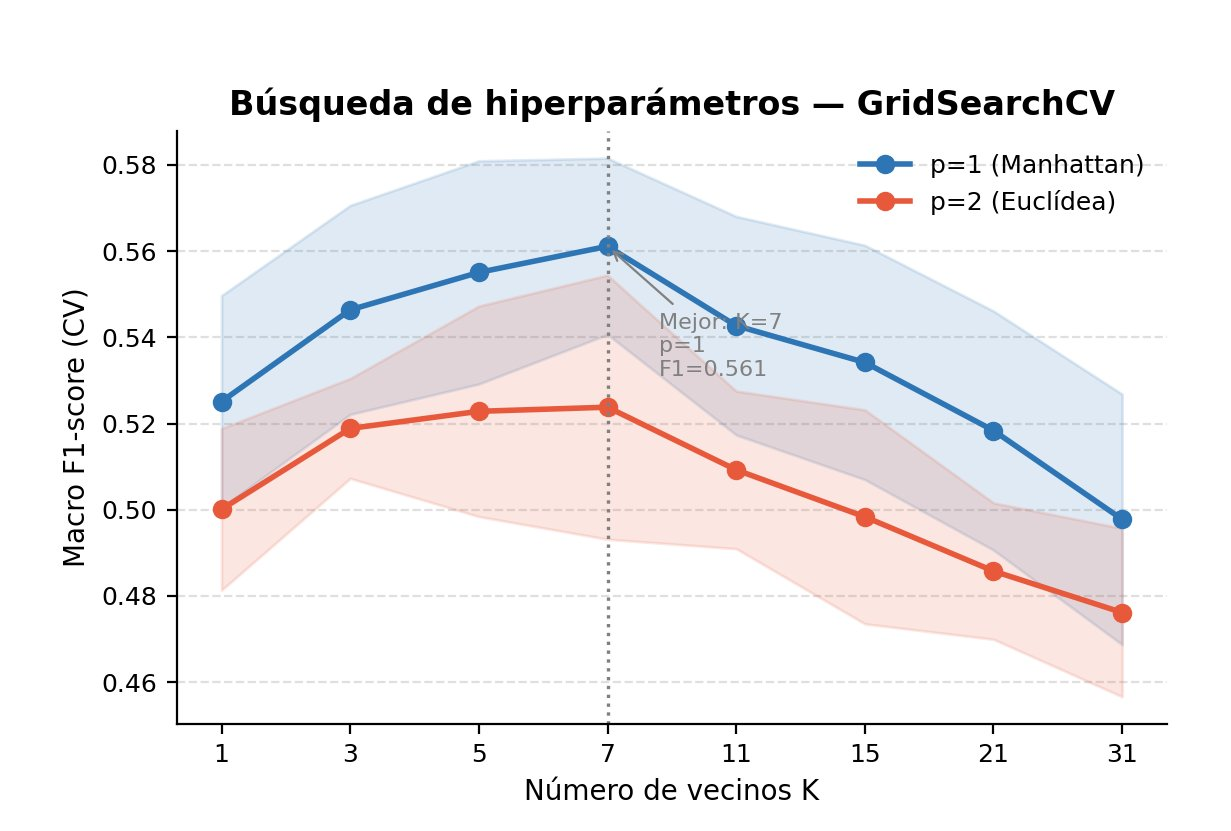

**¿Qué muestra?**
> Vamos probando en cada fold los distintos valores de K con ambas distancias, obteniendo un F1-score por cada combinación de (K,p). Al final de los 5 folds obtenemos una media de los F1 score de cada par (K,p) y los hemos representado en la gráfica para estudiar el comportamientos diversos al ir probando estos hiperparámetros y para entender cuáles son los óptimos

**¿Por qué Manhattan (p=1) supera a Euclídea (p=2) de forma consistente?**
> Esto tiene mucho sentido, si miramos la formula de la distancia Euclídea, vemos que se eleva cada diferencia al cuadrado antes de sumar todo. Eso hace que pocas features con diferencias grandes den representaciones distorsionadas sobre la distancia ya que obtienen un peso no siempre proporcional a su relevancia. Sin embargo, la distancia Manhattan suma las diferencias absolutas sin tener esa elevación al cuadrado. Eso hace que no se distribuya mal el peso entre todas las dimensiones. Terminamos entonces obteniendo con esa distancia unas medidas mucho menos sensibles a los ruidos del dataset y eso queda reflejado clarísimamente al visualizar los errores obtenidos en cross-validation independientemente del valor de K

**Trade-off bias-varianza con K:**

> El valor de K obtenido también es coherente, con K muy bajo memorizamos mucho el ruido del dataset y no generalizamos bien y con K demasiado elevado perdemos precisión local aumentando el sesgo.


**Resultado óptimo:** `K=7`, `p=1 (Manhattan)`, `Macro F1 (CV) = 0.561`

>K=7 no es un valor muy elevado y vemos que el rendimiento baja mucho en cuanto intentamos mirar más vecinos. Eso nos chiva algo interesante del dataset: los alumnos similares están muy cerca en el espacio de features, la frontera entre clases es bastante local y no tan global. Hay muchos subgrupos con comportamientos distintos y K=7 es suficiente para capturar la estrctura local.

---
## 2. Matriz de confusión (normalizada por fila)

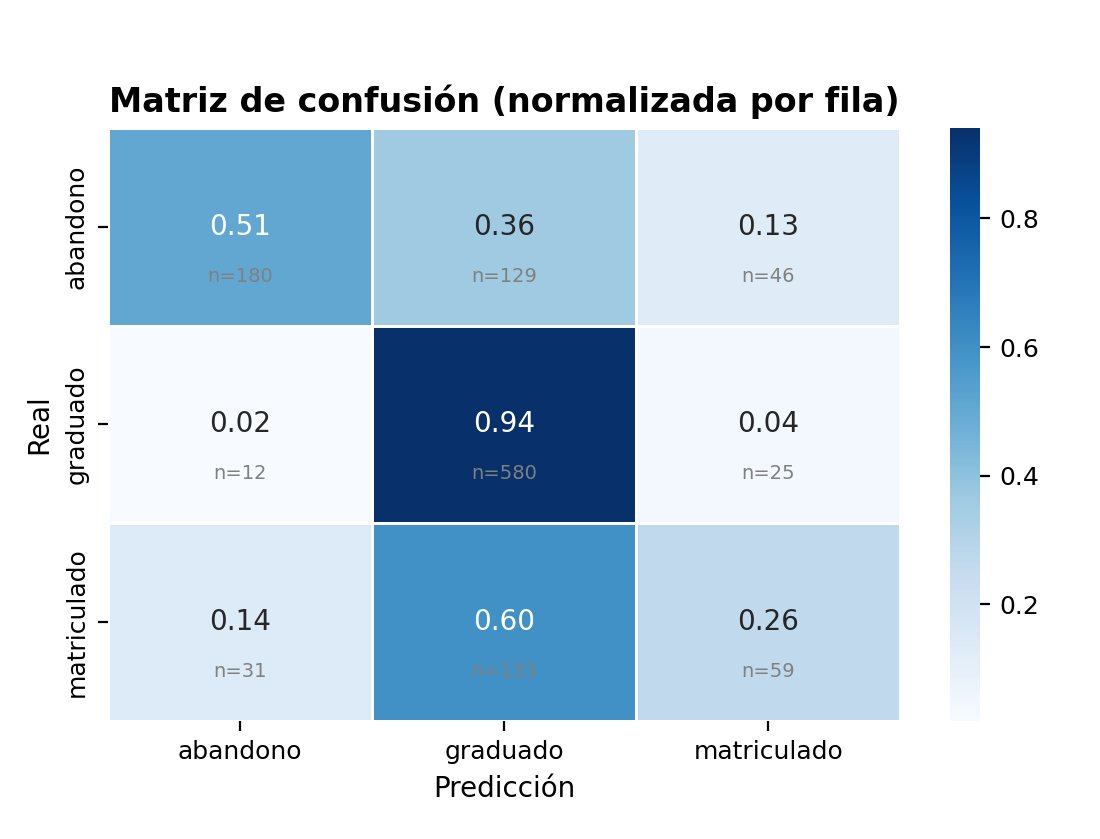

**EL MODELO ESTÁ COLAPSANDO HACIA GRADUADO**

> La matriz muestra un patrón muy claro: la columna de graduado acumula muchos errores de todas las otras clases. El 36% de los abandonos relaes se predicen como graduado y el 60% porciento de los matriculados reales también!!!

> Primera causa: el desbalanceo actúa de forma muy distinta en KNN que en regresión logística. En KNN, el mecanismo weights="distance" solo pondera el voto de cada vecino por su proximidad pero no corrige el hecho de que en el espacio de features hay muchos más puntos de graduado que de las otras clases. Cuando un punto de abandono o matriculado busca sus 7 vecinos más cercanos, la probabilidad de que de esos 7 haya mayoría de graduado es muy alta simplemente porque graduado ocupa más zona en el espacio de features!

> Segunda causa: la geometría del problema deja matriculado rodeado de graduados. Matriculado, por su naturaleza misma en el problema, vive en una región del espacio de features de transición que se solapa mucho con graduado. Un alumno matriculado tiene asignaturas evaluadas, matrícula al día,perfil académico activo... que es EXACTAMENTE las mismas features que un graduado a mitad de carrera. Por tanto, los vecinos más cercanos suelen ser mayoritariamente graduados y KNN no puede separar esa mezcla que reside en razones del problema. En abandono pasa algo parecido, algunos perfiles de abandono son muy parecidos a perfiles de graduado en primeros semestres, la universidad suele tener un comienzo duro para muchos hasta los que acaban graduandose.

> Tercera causa: la maldición de la dimensionalidad. Con 98 features, la distancias empiezan a igualarse y veremos estos en las gráficas siguiente.

> Cuarta causa: La multicolinealidad no se corrige como en regresión logística. En regresión logística, Lasso eliminaba muchos pesos por grupo, seleccionado representantes de cada bloque de features correlacionados. KNN no tiene un mecanismo equivalente que permite seleccionar automáticamente las variables. Por tanto, a la hora de computar las distnacias, las features correlacionadas están inflando artificialmente su peso en la decisión. El resultado es que el modelo piensa que la dimensión académica tiene mucho más peso de lo que realmente tiene. Por tanto, tiende a pensar que un matriculado con perfil académico activo parezca más cercano a graduado cuando por otras features más socioeconómicas podría no estarlo.

---
## 3. Precision, Recall y F1 por clase

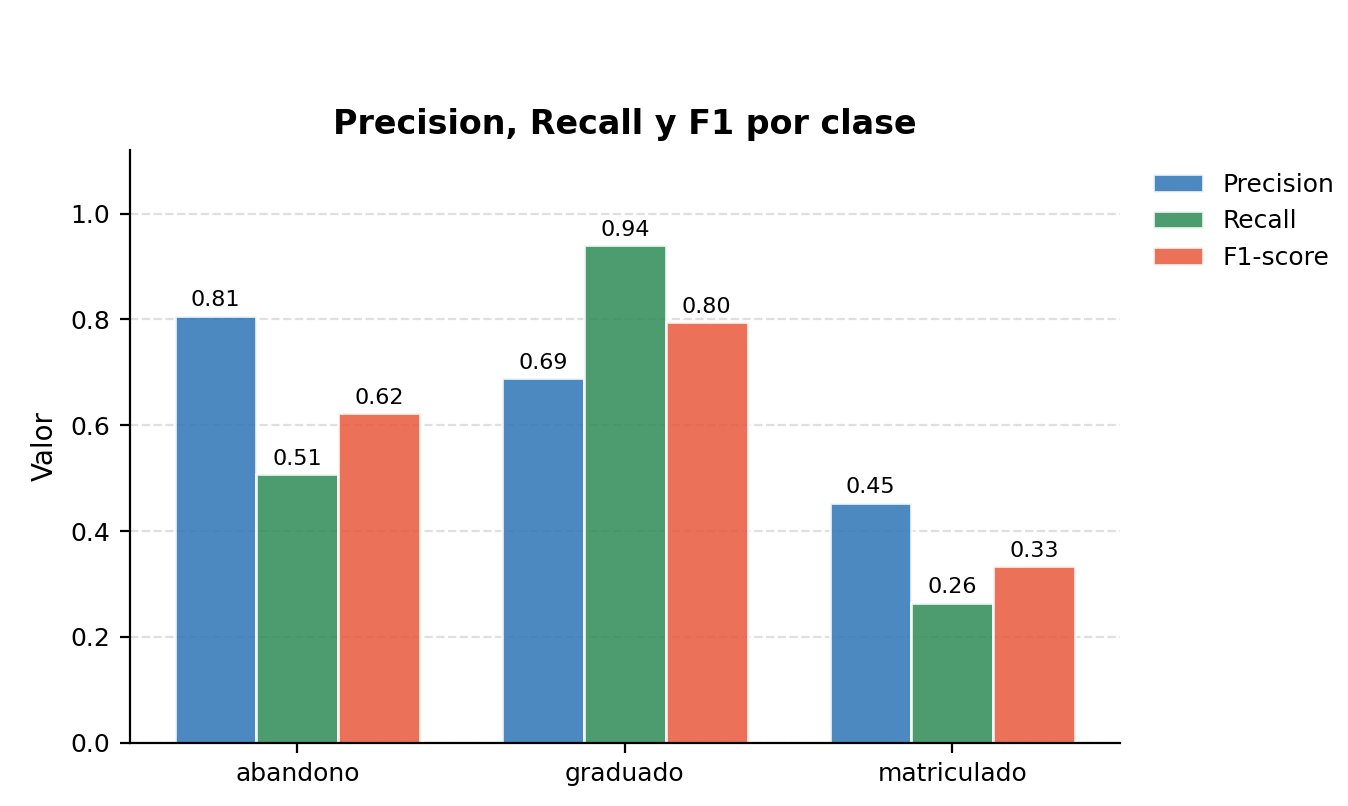


**¿Qué nos dice la comparativa?**
>Vemos que KNN comparado con regresión logística intercambia recall de abandono y matriculado por recall de graduado. Este comportamiento se explica en el análisis de la matriz anterior. El patrón global refleja un modelo bastante sesgado hacia graduado y eso lo manejaba mejor la regresión logística.



---
## 4. Distribución de distancias al K-ésimo vecino por clase

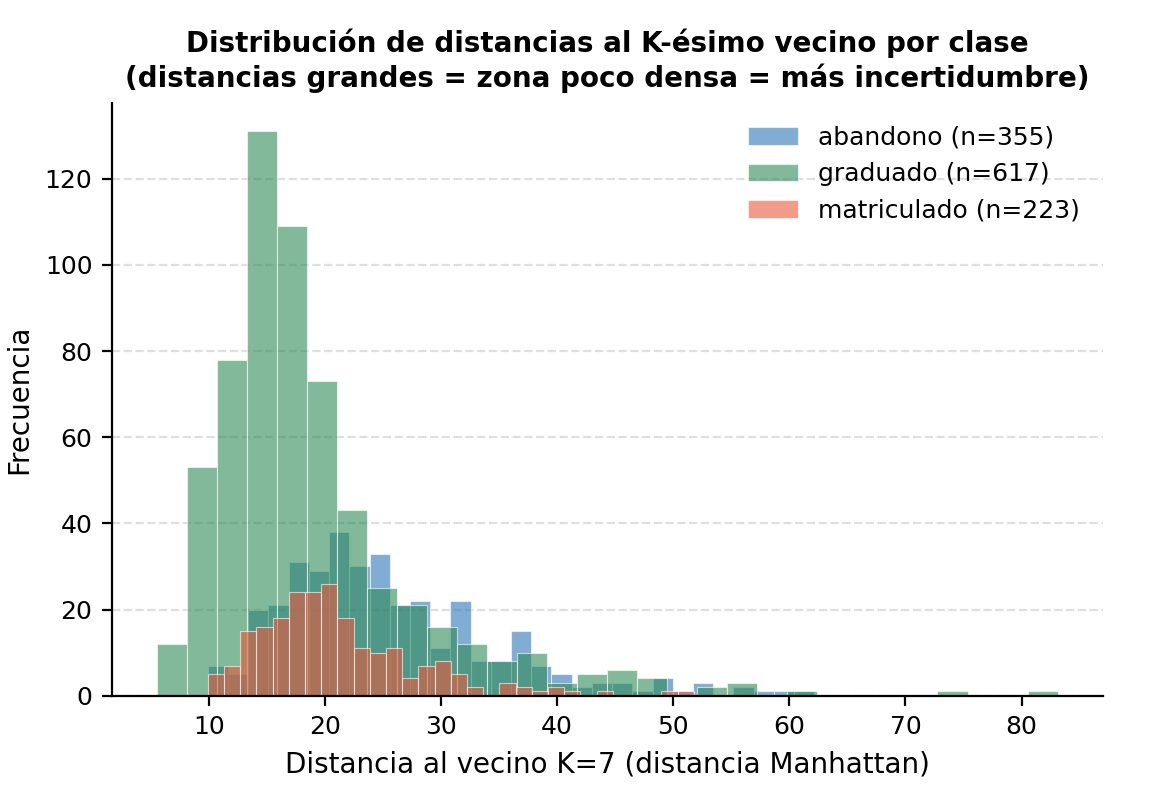

**¿Qué mide esta gráfica y por qué es específica de KNN?**
> Para cada dato de nuestro test, calculamos la distancia Manhattan a su septimo vecino más cercano en train. Con esa distancia podemos medir la densidad local que hay en el espacio de features. Si la distancia al séptimo punto es muy pequeña, significa que hay 6 más cercanos, por tanto es una zona densa y estará bien representada por KNN. Sin embargo, si hay distancias grandes, tenemos una zona más dispersa y el modelo consulta con vecinos más lejanos y por tanto hay más incertidumbre.

**¿Qué vemos por clase?**
> Vemos que la clase de graduado es claramente la más densa teniendo muchos vecinos cercanos. Eso se explica bien ya que es la clase con más muestras
> Las clases de abandono y matriculado presentan distribuciones más anchas barriendo distancias mayores. Esto nos chiva que el mal rendimiento de hemos visto en la matriz de confusión no ha sido provocado solo por un gran desbalanceo de clases sino que además las clases minoritarias ocupan regiones más dispersas en el espacio de features. Por tanto se suman varios factores que explican porqué el modelo ha captado mal esas clases. Además vemos el efecto directo de la maldición de la dimensionalidad ya que las distancias tienden a igualarse!!!

---
## 5. Conclusión — KNN 

<div style="border: 2px solid #2e86c1; border-radius: 8px; padding: 20px 24px; margin: 28px 0; background-color: #eaf4fb; color: #000000;">
<h3 style="color: #1a5276; margin-top: 0; padding-bottom: 8px; border-bottom: 1px solid #aed6f1; margin-bottom: 14px;">Conclusiones — KNN</h3>

Conclusión final obtenida trás el análisis de los resultados en el notebook:
El modelo KNN con K = 7 y distancia Manhattan obtiene un Macro F1 de 0.584 en test que queda muy por debajo de lo obtenido con regresión logística. Esto nos revela que este problema no conviene tratarlo con un clasificador que se basa en distancias locales y hemos detectado gracias a los resultados cuatro factores que lo explican.
Primero, el mecanismo weights = "distance" no corrige el desbalance de clases de forma tan efectiva como en class_weight="balanced" en regresión logística ya que no modifica la distribución de vecinos solo su peso de voto. 
Segundo, la geometría intrínseca del problema coloca a matriculado y abandono en regiones del espacio de features que se solapan con graduado. Este problema de naturaleza lo descubrimos en el modelo anterior y aquí se ve aún más claro: matriculado es una clase de transición que agrupa estudiantes con perfiles académicos activos que son muy parecidos a los graduados y también tiene algunos perfiles muy similares a los de abandono ya que al principio de la universidad es normal tener un perfil académico complicado. 
Tercero, con 98 dimensiones también aparece la maldición de la dimensionalidad que hace que las distancias entre puntos tiendan a igualarse y eso se confirma muy visualmente al ver las distribuciones de distancias al séptimo vecino.
Cuarto, la multicolinealidad entre las variables académicas que descubrimos al evaluar el modelo anterior y que se conseguía corregir automáticamente con Lasso no se soluciona con KNN. Por tanto, se inflan artificialmente los pesos de la dimensión académica al calcular las distancias haciendo que perfiles de matriculado con actividad académica alta parezcan más cercanos a graduado de lo que realmente son (las features socioeconómicas también tienen mucho que decir y quedan tapadas por esos falsos inflamientos). Por último, vemos que además del problema intrínseco de la naturaleza de "matriculado", vemos que las clases minoritarias tienen una gran dispersión geométrica aumentando aún más los problemas al tener que clasificarlos correctamente. Al final del proyecto haremos una comparativa entre los modelos de clasificación evaluando el impacto de tratar el desbalance con SMOTE en lugar de ponderación de clases.

</div>